# Empirical Prior Accuracy Sweep — Procedure 4

Systematic sweep of **Procedure 4** (Valle-Pérez et al. 2019) across architectures,
initialization schemes, widths, and depths.

For every configuration draw $M$ randomly-initialised networks and measure the fraction
of balanced probe points correctly labelled **before any training**.
Mean accuracy $> 0.5$ (chance) indicates the true labelling attracts non-trivial prior
mass under that architecture and init scheme.  Zero bias throughout so the baseline is
exactly $0.5$.

$$P_{\mathrm{init}}(f) \;\propto\; 2^{-K(f)}$$

## Sweep grid

| Axis | Values |
|------|--------|
| **Initialisations** | Uniform(−1,1) · Uniform(−0.2,0.2) · Kaiming Uniform · Kaiming Normal |
| **KINK + MLP** | widths [2,8,32,128,512] × depths [1–6] |
| **KINK + LeNet** | width multipliers [0.25,0.5,1,2,4,8,16] × depths [1–4] |
| **MNIST 0-vs-7 + MLP** | widths [16,32,64,128,256,512] (depth 1) |
| **MNIST 0-vs-7 + LeNet** | width multipliers [0.25,0.5,1,2,4,8,16] (depth 4, standard) |

Architecture configs match the SLURM sweep scripts (`kink_sample_sweep_mlp.sh`,
`kink_sample_sweep_lenet.sh`, `mnist_mlp_width_sweep.sh`, `mnist_lenet_width_sweep.sh`).
The training-set sample sizes from those scripts are contextual — the empirical prior is
measured on a fixed balanced probe set of $N_\text{probe}=100$ points.


In [10]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn
import torchvision

RNG = np.random.default_rng(42)

# ── Sweep parameters matching the SLURM scripts ───────────────────────────────
INITS = ['uniform', 'uniform_02', 'kaiming_uniform', 'kaiming_normal']
INIT_LABELS = {
    'uniform':         'Uniform(−1, 1)',
    'uniform_02':      'Uniform(−0.2, 0.2)',
    'kaiming_uniform': 'Kaiming Uniform',
    'kaiming_normal':  'Kaiming Normal',
}
INIT_COLORS = {
    'uniform':         'steelblue',
    'uniform_02':      'coral',
    'kaiming_uniform': 'seagreen',
    'kaiming_normal':  'mediumpurple',
}

KINK_MLP_WIDTHS   = [2, 8, 32, 128, 512]
KINK_MLP_DEPTHS   = [1, 2, 3, 4, 5, 6]

KINK_LENET_WIDTHS = [0.25, 0.5, 1, 2, 4, 8, 16]
KINK_LENET_DEPTHS = [1, 2, 3, 4]

MNIST_MLP_WIDTHS   = [16, 32, 64, 128, 256, 512]
MNIST_LENET_WIDTHS = [0.25, 0.5, 1, 2, 4, 8, 16]

M_INITS = 200    # random network draws per config (raise for tighter estimates)
N_PROBE = 100    # balanced probe points (50 per class)

os.makedirs('plots', exist_ok=True)
print("Parameters loaded.")
print(f"  M_INITS={M_INITS}, N_PROBE={N_PROBE}")
print(f"  Configs: KINK-MLP={len(INITS)*len(KINK_MLP_WIDTHS)*len(KINK_MLP_DEPTHS)}, "
      f"KINK-LeNet={len(INITS)*len(KINK_LENET_WIDTHS)*len(KINK_LENET_DEPTHS)}, "
      f"MNIST-MLP={len(INITS)*len(MNIST_MLP_WIDTHS)}, "
      f"MNIST-LeNet={len(INITS)*len(MNIST_LENET_WIDTHS)}")


Parameters loaded.
  M_INITS=200, N_PROBE=100
  Configs: KINK-MLP=120, KINK-LeNet=112, MNIST-MLP=24, MNIST-LeNet=28


In [11]:
# ── KINK dataset ──────────────────────────────────────────────────────────────
N_DATA = 2000

def make_kink(n=N_DATA, margin=0.25, seed=42):
    """Uniform samples in [-1,1]^2 with balanced binary label y > -|x|."""
    rng   = np.random.default_rng(seed)
    X     = rng.uniform(-1, 1, (n * 8, 2))
    dist  = X[:, 1] - (-np.abs(X[:, 0]))
    above = dist >  margin / 2
    below = dist < -margin / 2
    idx1  = np.where(above)[0][:n // 2]
    idx0  = np.where(below)[0][:n // 2]
    idx   = np.concatenate([idx0, idx1])
    rng.shuffle(idx)
    return X[idx], (above[idx]).astype(int)

X_kink, y_kink = make_kink()
print(f"KINK flat  : {X_kink.shape},  classes={np.bincount(y_kink)}")

# ── KINK → 28×28 single-channel image embedding ───────────────────────────────
def kink_to_images(X, img_size=28):
    pix  = ((X + 1) / 2 * (img_size - 1)).round().astype(int).clip(0, img_size - 1)
    imgs = np.zeros((len(X), 1, img_size, img_size), dtype=np.float32)
    for i, (px, py) in enumerate(pix):
        imgs[i, 0, py, px] = 1.0
    return imgs

X_kink_img = kink_to_images(X_kink)
print(f"KINK image : {X_kink_img.shape}")

# ── MNIST 0 vs 7 ──────────────────────────────────────────────────────────────
mnist_ds  = torchvision.datasets.MNIST('../data', train=True, download=True)
idx07     = (mnist_ds.targets == 0) | (mnist_ds.targets == 7)
X_mn_all  = mnist_ds.data[idx07].float().numpy()[:, None, :, :] / 255.0
y_mn_all  = (mnist_ds.targets[idx07] == 7).numpy().astype(int)
sel       = RNG.choice(len(X_mn_all), N_DATA, replace=False)
X_mnist_img  = X_mn_all[sel]                       # (N, 1, 28, 28) for LeNet
X_mnist_flat = X_mnist_img.reshape(N_DATA, -1)     # (N, 784)       for MLP
y_mnist      = y_mn_all[sel]
print(f"MNIST image: {X_mnist_img.shape}, classes={np.bincount(y_mnist)}")

# ── CIFAR-10 automobile (1) vs deer (4) ───────────────────────────────────────
cifar_ds   = torchvision.datasets.CIFAR10('../data', train=True, download=True)
cifar_tgts = np.array(cifar_ds.targets)
cifar_idx  = np.where((cifar_tgts == 1) | (cifar_tgts == 4))[0]
# cifar_ds.data is (N, H, W, C) uint8 → transpose to (N, C, H, W) float32
X_cf_all   = cifar_ds.data[cifar_idx].transpose(0, 3, 1, 2).astype(np.float32) / 255.0
y_cf_all   = (cifar_tgts[cifar_idx] == 4).astype(int)
sel_c      = RNG.choice(len(X_cf_all), N_DATA, replace=False)
X_cifar_img  = X_cf_all[sel_c]                      # (N, 3, 32, 32) for LeNet
X_cifar_flat = X_cifar_img.reshape(N_DATA, -1)      # (N, 3072)      for MLP
y_cifar      = y_cf_all[sel_c]
print(f"CIFAR image: {X_cifar_img.shape}, classes={np.bincount(y_cifar)}")
print(f"CIFAR flat : {X_cifar_flat.shape}")


KINK flat  : (2000, 2),  classes=[1000 1000]
KINK image : (2000, 1, 28, 28)
MNIST image: (2000, 1, 28, 28), classes=[ 976 1024]
CIFAR image: (2000, 3, 32, 32), classes=[1018  982]
CIFAR flat : (2000, 3072)


In [12]:
# ── Architecture 1: MLP ───────────────────────────────────────────────────────

class MLP(nn.Module):
    """
    Fully-connected ReLU network.
    `layers` hidden layers each of `width` units; output is 2-class logits.
    """
    def __init__(self, d_in: int, width: int, layers: int):
        super().__init__()
        sizes = [d_in] + [width] * layers + [2]
        mods  = []
        for i in range(len(sizes) - 1):
            mods.append(nn.Linear(sizes[i], sizes[i + 1], bias=True))
            if i < len(sizes) - 2:
                mods.append(nn.ReLU())
        self.net = nn.Sequential(*mods)

    def forward(self, x):
        return self.net(x)


# ── Architecture 2: Scalable LeNet ────────────────────────────────────────────
#
# depth=4  2c-3f  conv1→pool→conv2→pool→fc1→fc2→fc3  (standard LeNet)
# depth=3  2c-2f  drop fc1   →  conv…pool→fc2→fc3
# depth=2  2c-1f  drop fc1+fc2 → conv…pool→fc3
# depth=1  1c-1f  drop conv2+fc1+fc2 → conv1→pool→fc3
#
# width multiplier scales channel counts and FC layer widths.
# in_channels=1 for grayscale (KINK, MNIST); in_channels=3 for RGB (CIFAR-10).

class LeNet(nn.Module):
    def __init__(self, width: float = 1.0, depth: int = 4,
                 img_size: int = 28, n_classes: int = 2,
                 in_channels: int = 1):
        super().__init__()
        w = lambda base: max(1, round(base * width))

        self.depth = depth
        c1 = w(6); c2 = w(16); f1 = w(120); f2 = w(84)

        self.conv1 = nn.Conv2d(in_channels, c1, kernel_size=5)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()

        # Feature-map sizes after each block
        sz_after_c1 = (img_size - 4) // 2          # e.g. (28-4)//2=12, (32-4)//2=14
        sz_after_c2 = (sz_after_c1 - 4) // 2       # e.g. (12-4)//2=4,  (14-4)//2=5

        if depth >= 2:
            self.conv2  = nn.Conv2d(c1, c2, kernel_size=5)
            flat        = c2 * sz_after_c2 * sz_after_c2
        else:
            flat        = c1 * sz_after_c1 * sz_after_c1

        if depth >= 4:
            self.fc1 = nn.Linear(flat, f1)
            self.fc2 = nn.Linear(f1,   f2)
            self.fc3 = nn.Linear(f2,   n_classes)
        elif depth == 3:
            self.fc2 = nn.Linear(flat, f2)
            self.fc3 = nn.Linear(f2,   n_classes)
        else:               # depth 1 or 2
            self.fc3 = nn.Linear(flat, n_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        if self.depth >= 2:
            x = self.pool(self.relu(self.conv2(x)))
        x = x.flatten(1)
        if self.depth >= 4:
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
        elif self.depth == 3:
            x = self.relu(self.fc2(x))
        return self.fc3(x)


# Quick sanity checks
with torch.no_grad():
    _x2      = torch.zeros(4, 2)
    _x784    = torch.zeros(4, 784)
    _x3072   = torch.zeros(4, 3072)
    _img28   = torch.zeros(4, 1, 28, 28)
    _img32c3 = torch.zeros(4, 3, 32, 32)
    assert MLP(2,    32, 3)(_x2).shape    == (4, 2)
    assert MLP(784,  64, 1)(_x784).shape  == (4, 2)
    assert MLP(3072, 64, 1)(_x3072).shape == (4, 2)
    for d in [1, 2, 3, 4]:
        assert LeNet(width=1.0, depth=d, img_size=28)(_img28).shape   == (4, 2), f"28px depth={d}"
        assert LeNet(width=1.0, depth=d, img_size=32, in_channels=3)(_img32c3).shape == (4, 2), f"32px depth={d}"
    assert LeNet(width=16, depth=4)(_img28).shape == (4, 2)
print("Architecture sanity checks passed (including CIFAR 3-ch 32x32).")


Architecture sanity checks passed (including CIFAR 3-ch 32x32).


In [13]:
# ── Initialization schemes ────────────────────────────────────────────────────
# All schemes use zero bias so that the output distribution is symmetric under
# class flip → baseline accuracy is exactly 0.5 for balanced probe sets.

def apply_init(module: nn.Module, init_name: str) -> None:
    """Re-initialise all Linear and Conv2d weight tensors in-place."""
    for m in module.modules():
        if not isinstance(m, (nn.Linear, nn.Conv2d)):
            continue
        if init_name == 'uniform':
            nn.init.uniform_(m.weight, -1.0, 1.0)
        elif init_name == 'uniform_02':
            nn.init.uniform_(m.weight, -0.2, 0.2)
        elif init_name == 'kaiming_uniform':
            nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
        elif init_name == 'kaiming_normal':
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)


# ── Core empirical prior function ─────────────────────────────────────────────

def empirical_prior_net(model_factory, X: np.ndarray, y: np.ndarray,
                         init_name: str,
                         n_probe: int = N_PROBE,
                         m_inits: int = M_INITS,
                         seed: int = 7) -> dict:
    """
    Measure empirical prior accuracy for a given architecture + init scheme.

    Parameters
    ----------
    model_factory : () -> nn.Module   callable that constructs a fresh model
    X             : (N, ...)          input array (flat or NCHW image)
    y             : (N,)              binary labels
    init_name     : str               one of INITS

    Returns
    -------
    dict with keys: mean, std, p60, p70, accs (raw array of length m_inits)
    """
    rng  = np.random.default_rng(seed)
    idx0 = np.where(y == 0)[0]; idx1 = np.where(y == 1)[0]
    h    = n_probe // 2
    pidx = np.concatenate([rng.choice(idx0, h, replace=False),
                            rng.choice(idx1, h, replace=False)])

    X_p = torch.tensor(X[pidx], dtype=torch.float32)
    y_p = y[pidx]

    accs = np.empty(m_inits)
    for i in range(m_inits):
        torch.manual_seed(seed * 1_000_000 + i)
        model = model_factory()
        apply_init(model, init_name)
        model.eval()
        with torch.no_grad():
            pred = model(X_p).argmax(dim=1).numpy()
        accs[i] = (pred == y_p).mean()

    return {
        'mean': float(accs.mean()),
        'std':  float(accs.std()),
        'p60':  float((accs > 0.60).mean()),
        'p70':  float((accs > 0.70).mean()),
        'accs': accs,
    }


print("Init schemes and empirical_prior_net defined.")


Init schemes and empirical_prior_net defined.


In [14]:
# ── KINK + MLP sweep ──────────────────────────────────────────────────────────
# kink_mlp_res[init][width][depth] = {mean, std, p60, p70, accs}

kink_mlp_res = {}
total = len(INITS) * len(KINK_MLP_WIDTHS) * len(KINK_MLP_DEPTHS)
done  = 0

for init in INITS:
    kink_mlp_res[init] = {}
    for width in KINK_MLP_WIDTHS:
        kink_mlp_res[init][width] = {}
        for depth in KINK_MLP_DEPTHS:
            res = empirical_prior_net(
                lambda w=width, d=depth: MLP(d_in=2, width=w, layers=d),
                X_kink, y_kink, init_name=init
            )
            kink_mlp_res[init][width][depth] = res
            done += 1
            print(f"[{done:>3}/{total}] KINK-MLP  init={init:<18} "
                  f"w={width:>4}  d={depth}  "
                  f"mean={res['mean']:.4f}  std={res['std']:.4f}  "
                  f"p60={res['p60']:.3f}", flush=True)

print("\nKINK MLP sweep complete.")


[  1/120] KINK-MLP  init=uniform            w=   2  d=1  mean=0.5086  std=0.2173  p60=0.245
[  2/120] KINK-MLP  init=uniform            w=   2  d=2  mean=0.5217  std=0.1956  p60=0.235
[  3/120] KINK-MLP  init=uniform            w=   2  d=3  mean=0.4948  std=0.1887  p60=0.165
[  4/120] KINK-MLP  init=uniform            w=   2  d=4  mean=0.5079  std=0.1385  p60=0.105
[  5/120] KINK-MLP  init=uniform            w=   2  d=5  mean=0.4940  std=0.1301  p60=0.070
[  6/120] KINK-MLP  init=uniform            w=   2  d=6  mean=0.5061  std=0.0845  p60=0.060
[  7/120] KINK-MLP  init=uniform            w=   8  d=1  mean=0.4916  std=0.2513  p60=0.325
[  8/120] KINK-MLP  init=uniform            w=   8  d=2  mean=0.4881  std=0.2094  p60=0.235
[  9/120] KINK-MLP  init=uniform            w=   8  d=3  mean=0.5087  std=0.1829  p60=0.235
[ 10/120] KINK-MLP  init=uniform            w=   8  d=4  mean=0.5226  std=0.1542  p60=0.205
[ 11/120] KINK-MLP  init=uniform            w=   8  d=5  mean=0.5048  std=0.1385

In [15]:
# ── KINK + LeNet sweep ────────────────────────────────────────────────────────
# kink_lenet_res[init][width][depth] = {mean, std, p60, p70, accs}

kink_lenet_res = {}
total = len(INITS) * len(KINK_LENET_WIDTHS) * len(KINK_LENET_DEPTHS)
done  = 0

for init in INITS:
    kink_lenet_res[init] = {}
    for width in KINK_LENET_WIDTHS:
        kink_lenet_res[init][width] = {}
        for depth in KINK_LENET_DEPTHS:
            res = empirical_prior_net(
                lambda w=width, d=depth: LeNet(width=w, depth=d, img_size=28),
                X_kink_img, y_kink, init_name=init
            )
            kink_lenet_res[init][width][depth] = res
            done += 1
            print(f"[{done:>3}/{total}] KINK-LeNet init={init:<18} "
                  f"w={width:>5}  d={depth}  "
                  f"mean={res['mean']:.4f}  std={res['std']:.4f}  "
                  f"p60={res['p60']:.3f}", flush=True)

print("\nKINK LeNet sweep complete.")


[  1/112] KINK-LeNet init=uniform            w= 0.25  d=1  mean=0.5002  std=0.1028  p60=0.155
[  2/112] KINK-LeNet init=uniform            w= 0.25  d=2  mean=0.4906  std=0.1618  p60=0.240
[  3/112] KINK-LeNet init=uniform            w= 0.25  d=3  mean=0.5054  std=0.1309  p60=0.190
[  4/112] KINK-LeNet init=uniform            w= 0.25  d=4  mean=0.5034  std=0.1093  p60=0.170
[  5/112] KINK-LeNet init=uniform            w=  0.5  d=1  mean=0.5062  std=0.1042  p60=0.145
[  6/112] KINK-LeNet init=uniform            w=  0.5  d=2  mean=0.5120  std=0.1478  p60=0.280
[  7/112] KINK-LeNet init=uniform            w=  0.5  d=3  mean=0.4844  std=0.1265  p60=0.170
[  8/112] KINK-LeNet init=uniform            w=  0.5  d=4  mean=0.5124  std=0.1168  p60=0.185
[  9/112] KINK-LeNet init=uniform            w=    1  d=1  mean=0.4876  std=0.0950  p60=0.120
[ 10/112] KINK-LeNet init=uniform            w=    1  d=2  mean=0.4934  std=0.1638  p60=0.270
[ 11/112] KINK-LeNet init=uniform            w=    1  d=3  m

In [16]:
# ── MNIST + MLP sweep (full width × depth, matching KINK grid) ────────────────
# mnist_mlp_res[init][width][depth] = {mean, std, p60, p70, accs}

mnist_mlp_res = {}
total = len(INITS) * len(KINK_MLP_WIDTHS) * len(KINK_MLP_DEPTHS)
done  = 0

for init in INITS:
    mnist_mlp_res[init] = {}
    for width in KINK_MLP_WIDTHS:
        mnist_mlp_res[init][width] = {}
        for depth in KINK_MLP_DEPTHS:
            res = empirical_prior_net(
                lambda w=width, d=depth: MLP(d_in=784, width=w, layers=d),
                X_mnist_flat, y_mnist, init_name=init
            )
            mnist_mlp_res[init][width][depth] = res
            done += 1
            print(f"[{done:>3}/{total}] MNIST-MLP  init={init:<18} "
                  f"w={width:>4}  d={depth}  "
                  f"mean={res['mean']:.4f}  std={res['std']:.4f}  "
                  f"p60={res['p60']:.3f}", flush=True)

print("\nMNIST MLP sweep complete.")


[  1/120] MNIST-MLP  init=uniform            w=   2  d=1  mean=0.5004  std=0.1033  p60=0.130
[  2/120] MNIST-MLP  init=uniform            w=   2  d=2  mean=0.4870  std=0.0913  p60=0.085
[  3/120] MNIST-MLP  init=uniform            w=   2  d=3  mean=0.4968  std=0.0831  p60=0.080
[  4/120] MNIST-MLP  init=uniform            w=   2  d=4  mean=0.4915  std=0.0608  p60=0.020
[  5/120] MNIST-MLP  init=uniform            w=   2  d=5  mean=0.5014  std=0.0465  p60=0.025
[  6/120] MNIST-MLP  init=uniform            w=   2  d=6  mean=0.4950  std=0.0464  p60=0.025
[  7/120] MNIST-MLP  init=uniform            w=   8  d=1  mean=0.5120  std=0.1139  p60=0.195
[  8/120] MNIST-MLP  init=uniform            w=   8  d=2  mean=0.5040  std=0.0856  p60=0.125
[  9/120] MNIST-MLP  init=uniform            w=   8  d=3  mean=0.5049  std=0.0885  p60=0.090
[ 10/120] MNIST-MLP  init=uniform            w=   8  d=4  mean=0.5005  std=0.0807  p60=0.090
[ 11/120] MNIST-MLP  init=uniform            w=   8  d=5  mean=0.5020 

In [17]:
# ── MNIST + LeNet sweep (full width × depth, matching KINK grid) ──────────────
# mnist_lenet_res[init][width][depth] = {mean, std, p60, p70, accs}

mnist_lenet_res = {}
total = len(INITS) * len(KINK_LENET_WIDTHS) * len(KINK_LENET_DEPTHS)
done  = 0

for init in INITS:
    mnist_lenet_res[init] = {}
    for width in KINK_LENET_WIDTHS:
        mnist_lenet_res[init][width] = {}
        for depth in KINK_LENET_DEPTHS:
            res = empirical_prior_net(
                lambda w=width, d=depth: LeNet(width=w, depth=d, img_size=28),
                X_mnist_img, y_mnist, init_name=init
            )
            mnist_lenet_res[init][width][depth] = res
            done += 1
            print(f"[{done:>3}/{total}] MNIST-LeNet init={init:<18} "
                  f"w={width:>5}  d={depth}  "
                  f"mean={res['mean']:.4f}  std={res['std']:.4f}  "
                  f"p60={res['p60']:.3f}", flush=True)

print("\nMNIST LeNet sweep complete.")


[  1/112] MNIST-LeNet init=uniform            w= 0.25  d=1  mean=0.5022  std=0.1438  p60=0.200
[  2/112] MNIST-LeNet init=uniform            w= 0.25  d=2  mean=0.5153  std=0.1335  p60=0.195
[  3/112] MNIST-LeNet init=uniform            w= 0.25  d=3  mean=0.4979  std=0.1037  p60=0.110
[  4/112] MNIST-LeNet init=uniform            w= 0.25  d=4  mean=0.4993  std=0.1067  p60=0.140
[  5/112] MNIST-LeNet init=uniform            w=  0.5  d=1  mean=0.4794  std=0.1425  p60=0.180
[  6/112] MNIST-LeNet init=uniform            w=  0.5  d=2  mean=0.5040  std=0.1100  p60=0.100
[  7/112] MNIST-LeNet init=uniform            w=  0.5  d=3  mean=0.5116  std=0.1139  p60=0.155
[  8/112] MNIST-LeNet init=uniform            w=  0.5  d=4  mean=0.4898  std=0.0935  p60=0.065
[  9/112] MNIST-LeNet init=uniform            w=    1  d=1  mean=0.4877  std=0.1327  p60=0.170
[ 10/112] MNIST-LeNet init=uniform            w=    1  d=2  mean=0.5044  std=0.1284  p60=0.155
[ 11/112] MNIST-LeNet init=uniform            w=  

In [18]:
# ── CIFAR-10 + MLP sweep (full width × depth, matching KINK grid) ─────────────
# cifar_mlp_res[init][width][depth] = {mean, std, p60, p70, accs}

cifar_mlp_res = {}
total = len(INITS) * len(KINK_MLP_WIDTHS) * len(KINK_MLP_DEPTHS)
done  = 0

for init in INITS:
    cifar_mlp_res[init] = {}
    for width in KINK_MLP_WIDTHS:
        cifar_mlp_res[init][width] = {}
        for depth in KINK_MLP_DEPTHS:
            res = empirical_prior_net(
                lambda w=width, d=depth: MLP(d_in=3072, width=w, layers=d),
                X_cifar_flat, y_cifar, init_name=init
            )
            cifar_mlp_res[init][width][depth] = res
            done += 1
            print(f"[{done:>3}/{total}] CIFAR-MLP  init={init:<18} "
                  f"w={width:>4}  d={depth}  "
                  f"mean={res['mean']:.4f}  std={res['std']:.4f}  "
                  f"p60={res['p60']:.3f}", flush=True)

print("\nCIFAR MLP sweep complete.")


[  1/120] CIFAR-MLP  init=uniform            w=   2  d=1  mean=0.5005  std=0.0479  p60=0.035
[  2/120] CIFAR-MLP  init=uniform            w=   2  d=2  mean=0.5032  std=0.0428  p60=0.030
[  3/120] CIFAR-MLP  init=uniform            w=   2  d=3  mean=0.5002  std=0.0317  p60=0.015
[  4/120] CIFAR-MLP  init=uniform            w=   2  d=4  mean=0.4978  std=0.0304  p60=0.005
[  5/120] CIFAR-MLP  init=uniform            w=   2  d=5  mean=0.5000  std=0.0282  p60=0.015
[  6/120] CIFAR-MLP  init=uniform            w=   2  d=6  mean=0.5025  std=0.0288  p60=0.030
[  7/120] CIFAR-MLP  init=uniform            w=   8  d=1  mean=0.4928  std=0.0563  p60=0.035
[  8/120] CIFAR-MLP  init=uniform            w=   8  d=2  mean=0.5019  std=0.0497  p60=0.035
[  9/120] CIFAR-MLP  init=uniform            w=   8  d=3  mean=0.5075  std=0.0465  p60=0.035
[ 10/120] CIFAR-MLP  init=uniform            w=   8  d=4  mean=0.4986  std=0.0352  p60=0.020
[ 11/120] CIFAR-MLP  init=uniform            w=   8  d=5  mean=0.5082 

In [19]:
# ── CIFAR-10 + LeNet sweep (img_size=32, in_channels=3, full width × depth) ────
# cifar_lenet_res[init][width][depth] = {mean, std, p60, p70, accs}

cifar_lenet_res = {}
total = len(INITS) * len(KINK_LENET_WIDTHS) * len(KINK_LENET_DEPTHS)
done  = 0

for init in INITS:
    cifar_lenet_res[init] = {}
    for width in KINK_LENET_WIDTHS:
        cifar_lenet_res[init][width] = {}
        for depth in KINK_LENET_DEPTHS:
            res = empirical_prior_net(
                lambda w=width, d=depth: LeNet(width=w, depth=d, img_size=32, in_channels=3),
                X_cifar_img, y_cifar, init_name=init
            )
            cifar_lenet_res[init][width][depth] = res
            done += 1
            print(f"[{done:>3}/{total}] CIFAR-LeNet init={init:<18} "
                  f"w={width:>5}  d={depth}  "
                  f"mean={res['mean']:.4f}  std={res['std']:.4f}  "
                  f"p60={res['p60']:.3f}", flush=True)

print("\nCIFAR LeNet sweep complete.")
print("\nAll sweeps done.")


[  1/112] CIFAR-LeNet init=uniform            w= 0.25  d=1  mean=0.4931  std=0.0606  p60=0.035
[  2/112] CIFAR-LeNet init=uniform            w= 0.25  d=2  mean=0.4945  std=0.0537  p60=0.005
[  3/112] CIFAR-LeNet init=uniform            w= 0.25  d=3  mean=0.4943  std=0.0580  p60=0.015
[  4/112] CIFAR-LeNet init=uniform            w= 0.25  d=4  mean=0.4934  std=0.0488  p60=0.015
[  5/112] CIFAR-LeNet init=uniform            w=  0.5  d=1  mean=0.4973  std=0.0612  p60=0.025
[  6/112] CIFAR-LeNet init=uniform            w=  0.5  d=2  mean=0.4995  std=0.0513  p60=0.030
[  7/112] CIFAR-LeNet init=uniform            w=  0.5  d=3  mean=0.4950  std=0.0511  p60=0.035
[  8/112] CIFAR-LeNet init=uniform            w=  0.5  d=4  mean=0.5069  std=0.0410  p60=0.020
[  9/112] CIFAR-LeNet init=uniform            w=    1  d=1  mean=0.4921  std=0.0520  p60=0.015
[ 10/112] CIFAR-LeNet init=uniform            w=    1  d=2  mean=0.5000  std=0.0519  p60=0.045
[ 11/112] CIFAR-LeNet init=uniform            w=  

## Combined visualisations — all three datasets × all four initialisations

Each figure shows a **3 × 4 grid**: rows = datasets (KINK, MNIST 0 vs 7, CIFAR-10 auto vs deer),
columns = init schemes.  Every cell is a heatmap of mean prior accuracy across the
width × depth sweep grid.  Colour scale: red = below chance (0.50), green = above chance.

Two output figures:
- `plots/prior_all_mlp.png`    — flat MLP, same widths [2,8,32,128,512] × depths [1–6] for all datasets
- `plots/prior_all_lenet.png`  — scalable LeNet, same width multipliers × depths [1–4] for all datasets


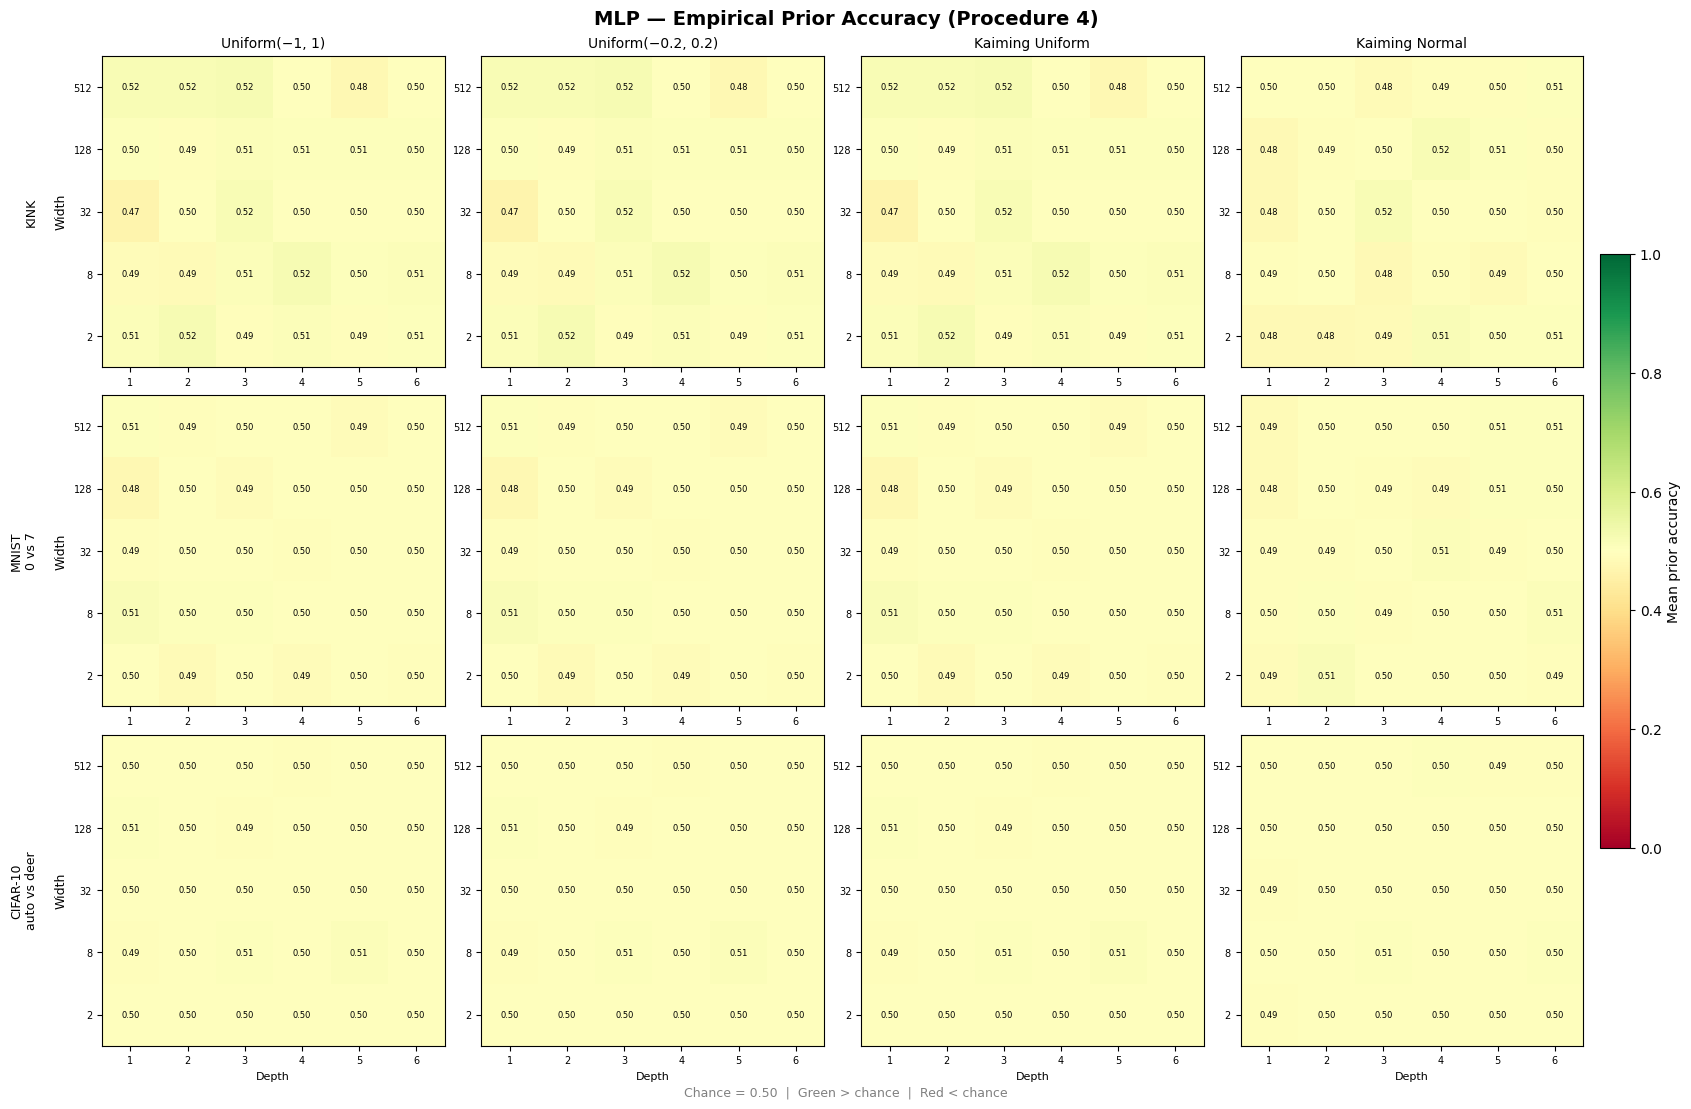

Saved plots/prior_all_mlp.png


In [20]:
norm = mcolors.TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)

# Dataset display labels (row headers)
DS_LABEL = {
    'KINK':     'KINK',
    'MNIST':    'MNIST\n0 vs 7',
    'CIFAR-10': 'CIFAR-10\nauto vs deer',
}

def plot_combined_heatmaps(all_res, widths, depths, arch_name, fname):
    """
    3-dataset × 4-init grid of prior-accuracy heatmaps.

    Parameters
    ----------
    all_res  : dict  {'KINK': res, 'MNIST': res, 'CIFAR-10': res}
               where res[init][width][depth] = {'mean': float, ...}
    widths   : list  y-axis values
    depths   : list  x-axis values
    arch_name: str   figure title prefix
    fname    : str   save path
    """
    datasets   = list(all_res.keys())
    n_ds       = len(datasets)
    n_init     = len(INITS)

    fig, axes = plt.subplots(
        n_ds, n_init,
        figsize=(4.2 * n_init, 3.6 * n_ds),
        constrained_layout=True,
    )
    fig.suptitle(f'{arch_name} — Empirical Prior Accuracy (Procedure 4)',
                 fontsize=14, fontweight='bold')

    # Column titles = init names
    for ci, init in enumerate(INITS):
        axes[0, ci].set_title(INIT_LABELS[init], fontsize=10)

    im = None
    for ri, ds in enumerate(datasets):
        results = all_res[ds]
        # Row label on left-most column
        axes[ri, 0].set_ylabel(f'{DS_LABEL[ds]}\n\nWidth', fontsize=9)

        for ci, init in enumerate(INITS):
            ax  = axes[ri, ci]
            mat = np.array([[results[init][w][d]['mean']
                             for d in depths] for w in widths])
            im  = ax.imshow(mat, aspect='auto', norm=norm, cmap='RdYlGn',
                            origin='lower')
            ax.set_xticks(range(len(depths)))
            ax.set_xticklabels(depths, fontsize=7)
            ax.set_yticks(range(len(widths)))
            ax.set_yticklabels(widths, fontsize=7)
            if ri == n_ds - 1:
                ax.set_xlabel('Depth', fontsize=8)

            # Annotate each cell
            for r2 in range(len(widths)):
                for c2 in range(len(depths)):
                    v = mat[r2, c2]
                    ax.text(c2, r2, f'{v:.2f}', ha='center', va='center',
                            fontsize=6,
                            color='black' if 0.35 < v < 0.65 else 'white')

    fig.colorbar(im, ax=axes[:, -1], label='Mean prior accuracy', shrink=0.6)
    fig.text(0.5, -0.01,
             'Chance = 0.50  |  Green > chance  |  Red < chance',
             ha='center', fontsize=9, color='gray')

    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")


# ── MLP combined: KINK + MNIST + CIFAR ────────────────────────────────────────
mlp_all_res = {
    'KINK':     kink_mlp_res,
    'MNIST':    mnist_mlp_res,
    'CIFAR-10': cifar_mlp_res,
}

plot_combined_heatmaps(
    mlp_all_res,
    widths    = KINK_MLP_WIDTHS,
    depths    = KINK_MLP_DEPTHS,
    arch_name = 'MLP',
    fname     = 'plots/prior_all_mlp.png',
)


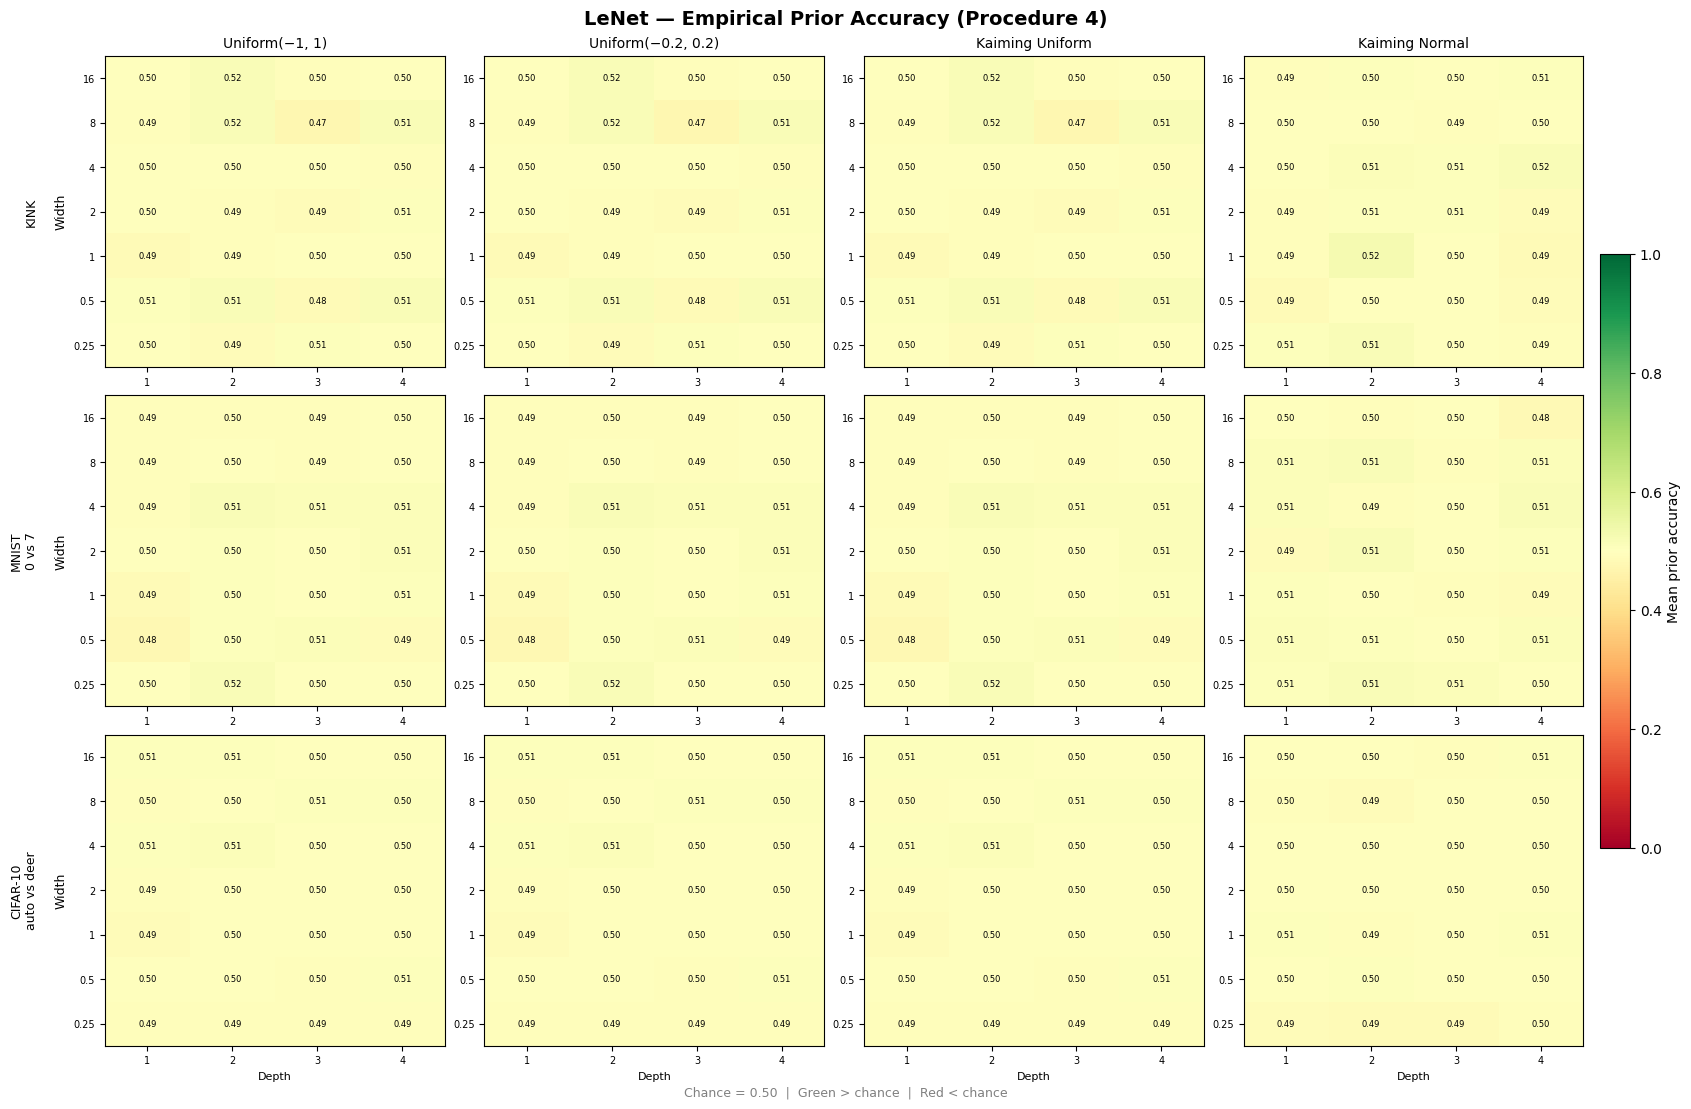

Saved plots/prior_all_lenet.png


In [21]:
# ── LeNet combined: KINK + MNIST + CIFAR ──────────────────────────────────────
lenet_all_res = {
    'KINK':     kink_lenet_res,
    'MNIST':    mnist_lenet_res,
    'CIFAR-10': cifar_lenet_res,
}

plot_combined_heatmaps(
    lenet_all_res,
    widths    = KINK_LENET_WIDTHS,
    depths    = KINK_LENET_DEPTHS,
    arch_name = 'LeNet',
    fname     = 'plots/prior_all_lenet.png',
)


## Diagnostic: p60 vs N_probe

The uniform mean = 0.50 is guaranteed by symmetry (zero bias + symmetric init).
The relevant signal is in the **tail** of the accuracy distribution: the fraction of
random networks that, by chance, implement the true labeling on all probe points.

With large N_probe these "lucky" networks are swamped by the binomial floor.
Sweeping N_probe reveals whether any dataset separates from the random baseline, and
at what probe-set size the signal is strongest.

**Setup**: one representative architecture (MLP width = 64, depth = 2) across all three
datasets and all four init schemes, N_probe ∈ {5, 10, 20, 50, 100}, M = 500 draws.
**Metric**: p60 = fraction of networks with accuracy > 0.60 on the balanced probe.
**Baseline**: P(Bin(N_probe, 0.5) > 0.6 × N_probe) — expected p60 for a fully random network.


In [22]:
from scipy.stats import binom as _binom

N_PROBE_VALS   = [5, 10, 20, 50, 100]
M_INITS_DIAG   = 500
DIAG_MLP_WIDTH = 64;  DIAG_MLP_DEPTH  = 2    # representative MLP
DIAG_LN_WIDTH  = 1.0; DIAG_LN_DEPTH   = 4    # standard LeNet-5

# (dataset_name, X_flat,      y,       input_dim)
_diag_mlp_ds = [
    ('KINK',     X_kink,       y_kink,  2),
    ('MNIST',    X_mnist_flat, y_mnist, 784),
    ('CIFAR-10', X_cifar_flat, y_cifar, 3072),
]
# (dataset_name, X_img,       y,       img_size, in_channels)
_diag_lenet_ds = [
    ('KINK',     X_kink_img,  y_kink,  28, 1),
    ('MNIST',    X_mnist_img, y_mnist, 28, 1),
    ('CIFAR-10', X_cifar_img, y_cifar, 32, 3),
]

DS_NAMES = ['KINK', 'MNIST', 'CIFAR-10']

# nprobe_mlp_res[ds][init][n_probe]  and  nprobe_lenet_res[ds][init][n_probe]
nprobe_mlp_res   = {ds: {init: {} for init in INITS} for ds in DS_NAMES}
nprobe_lenet_res = {ds: {init: {} for init in INITS} for ds in DS_NAMES}

total = 2 * len(N_PROBE_VALS) * len(DS_NAMES) * len(INITS)
done  = 0

for n_probe in N_PROBE_VALS:
    # ── MLP ───────────────────────────────────────────────────────────────────
    for ds_name, X, y, d_in in _diag_mlp_ds:
        for init in INITS:
            res = empirical_prior_net(
                lambda d=d_in: MLP(d_in=d, width=DIAG_MLP_WIDTH, layers=DIAG_MLP_DEPTH),
                X, y, init_name=init, n_probe=n_probe, m_inits=M_INITS_DIAG,
            )
            nprobe_mlp_res[ds_name][init][n_probe] = res
            done += 1
            print(f"[{done:>3}/{total}] N={n_probe:>3}  MLP   "
                  f"  {ds_name:<10}  {init:<18}  "
                  f"mean={res['mean']:.3f}  std={res['std']:.3f}  "
                  f"p60={res['p60']:.3f}  p70={res['p70']:.3f}", flush=True)

    # ── LeNet ─────────────────────────────────────────────────────────────────
    for ds_name, X, y, img_size, in_ch in _diag_lenet_ds:
        for init in INITS:
            res = empirical_prior_net(
                lambda s=img_size, c=in_ch: LeNet(
                    width=DIAG_LN_WIDTH, depth=DIAG_LN_DEPTH,
                    img_size=s, in_channels=c,
                ),
                X, y, init_name=init, n_probe=n_probe, m_inits=M_INITS_DIAG,
            )
            nprobe_lenet_res[ds_name][init][n_probe] = res
            done += 1
            print(f"[{done:>3}/{total}] N={n_probe:>3}  LeNet "
                  f"  {ds_name:<10}  {init:<18}  "
                  f"mean={res['mean']:.3f}  std={res['std']:.3f}  "
                  f"p60={res['p60']:.3f}  p70={res['p70']:.3f}", flush=True)

print("\nN_probe sweep (MLP + LeNet) complete.")


[  1/120] N=  5  MLP     KINK        uniform             mean=0.500  std=0.274  p60=0.252  p70=0.252
[  2/120] N=  5  MLP     KINK        uniform_02          mean=0.500  std=0.274  p60=0.252  p70=0.252
[  3/120] N=  5  MLP     KINK        kaiming_uniform     mean=0.500  std=0.274  p60=0.252  p70=0.252
[  4/120] N=  5  MLP     KINK        kaiming_normal      mean=0.485  std=0.282  p60=0.252  p70=0.252
[  5/120] N=  5  MLP     MNIST       uniform             mean=0.495  std=0.191  p60=0.186  p70=0.186
[  6/120] N=  5  MLP     MNIST       uniform_02          mean=0.495  std=0.191  p60=0.186  p70=0.186
[  7/120] N=  5  MLP     MNIST       kaiming_uniform     mean=0.495  std=0.191  p60=0.186  p70=0.186
[  8/120] N=  5  MLP     MNIST       kaiming_normal      mean=0.502  std=0.200  p60=0.228  p70=0.228
[  9/120] N=  5  MLP     CIFAR-10    uniform             mean=0.502  std=0.138  p60=0.122  p70=0.122
[ 10/120] N=  5  MLP     CIFAR-10    uniform_02          mean=0.502  std=0.138  p60=0.122  

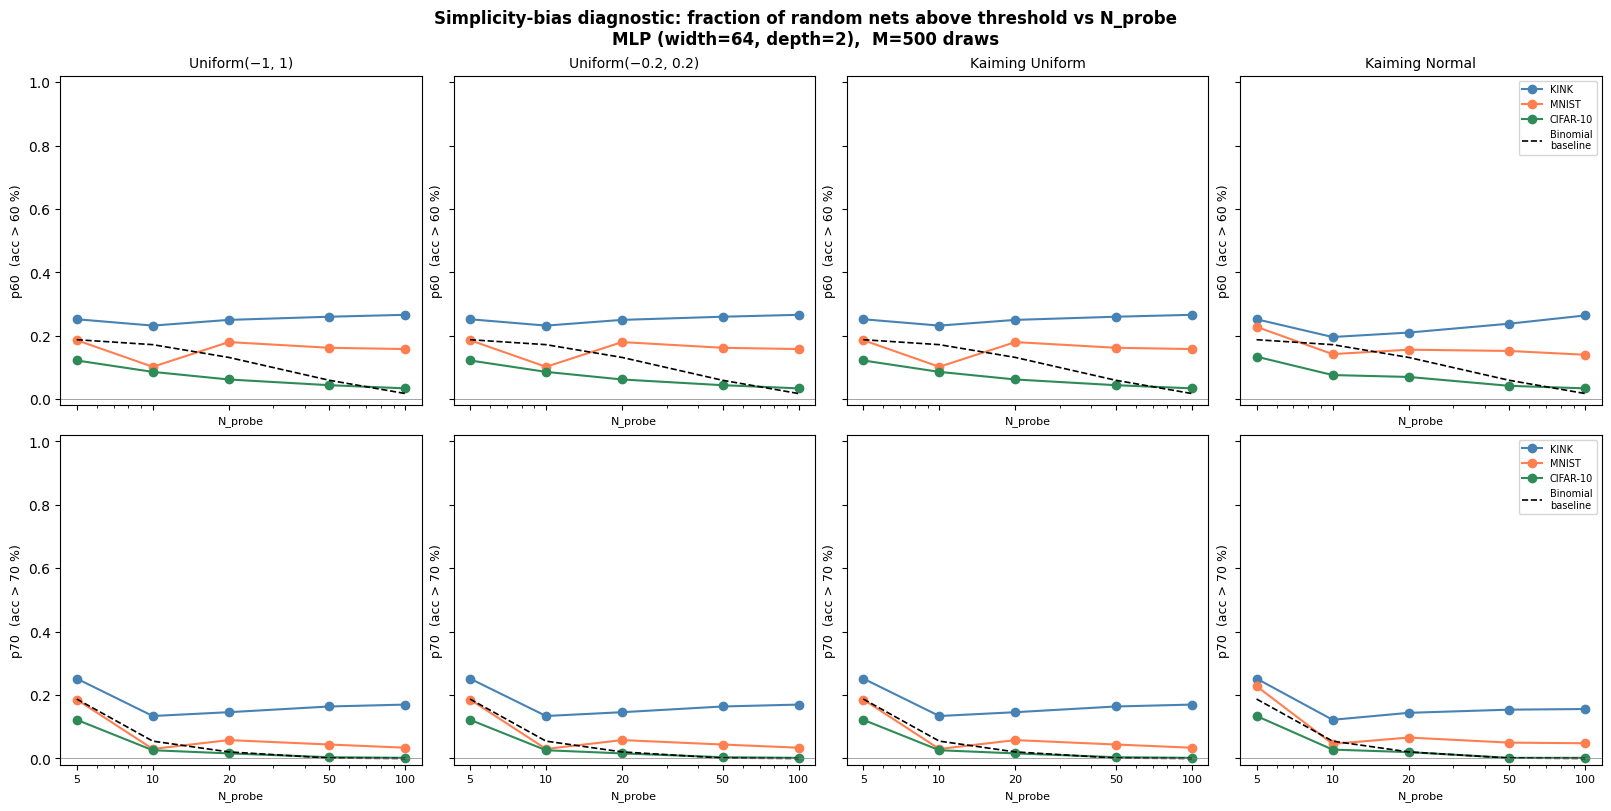

Saved plots/nprobe_sweep_mlp.png


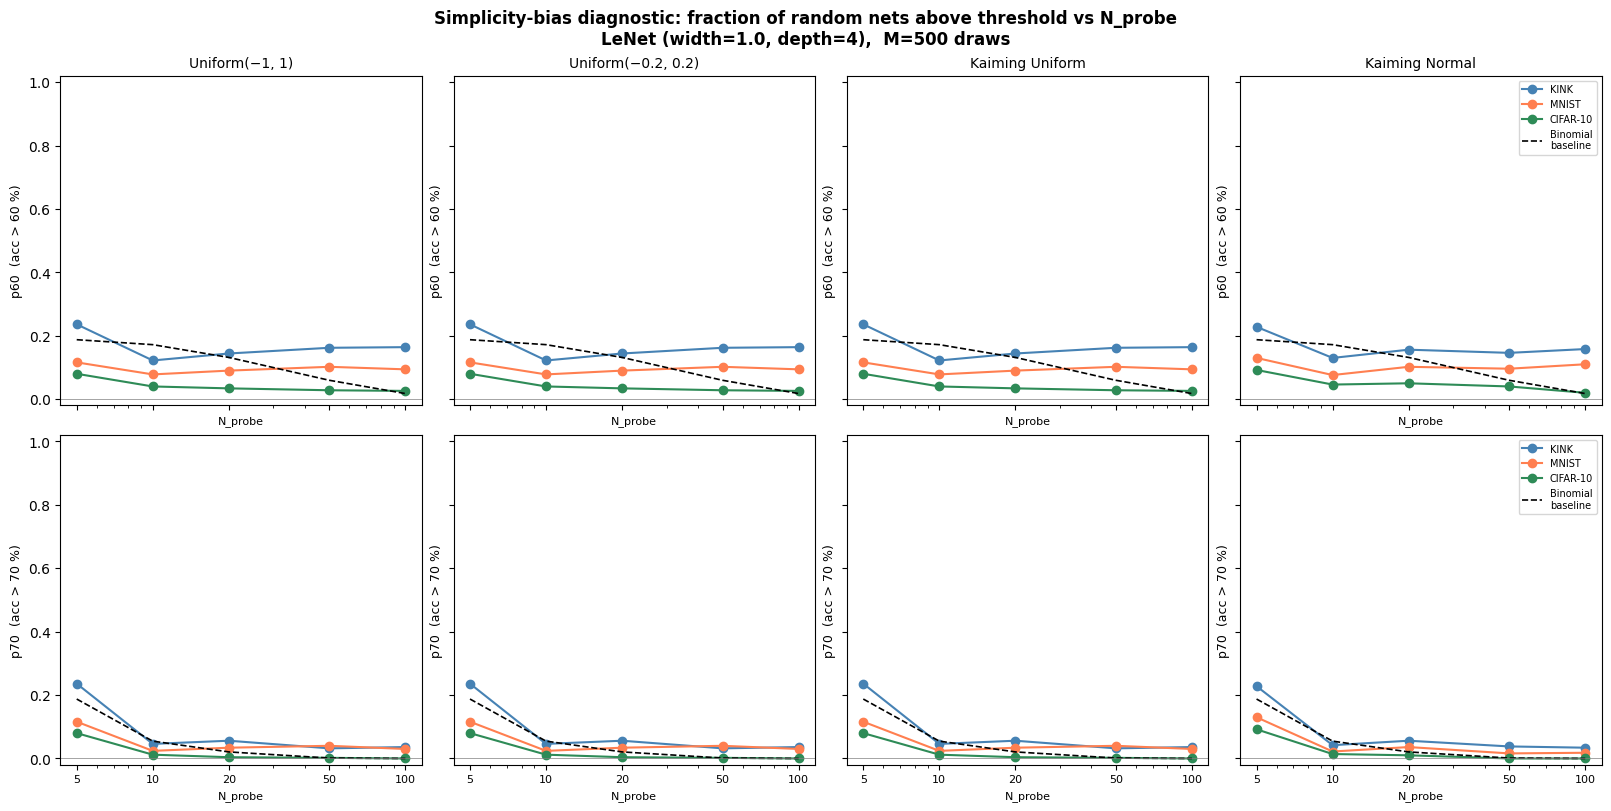

Saved plots/nprobe_sweep_lenet.png


In [23]:
DS_COLORS = {'KINK': 'steelblue', 'MNIST': 'coral', 'CIFAR-10': 'seagreen'}

# Binomial baseline: P(Bin(n, 0.5) > threshold * n)
baseline_p60 = {n: 1 - _binom.cdf(int(0.6 * n), n, 0.5) for n in N_PROBE_VALS}
baseline_p70 = {n: 1 - _binom.cdf(int(0.7 * n), n, 0.5) for n in N_PROBE_VALS}


def plot_nprobe_diagnostic(nprobe_res, arch_name, diag_width, diag_depth, fname):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey='row', sharex=True,
                             constrained_layout=True)
    fig.suptitle(
        f'Simplicity-bias diagnostic: fraction of random nets above threshold vs N_probe\n'
        f'{arch_name} (width={diag_width}, depth={diag_depth}),  M={M_INITS_DIAG} draws',
        fontsize=12, fontweight='bold',
    )

    for row, (metric_key, threshold_label, baseline) in enumerate([
        ('p60', 'p60  (acc > 60 %)', baseline_p60),
        ('p70', 'p70  (acc > 70 %)', baseline_p70),
    ]):
        for ci, init in enumerate(INITS):
            ax = axes[row, ci]
            if row == 0:
                ax.set_title(INIT_LABELS[init], fontsize=10)
            ax.set_ylabel(threshold_label, fontsize=9)

            for ds_name in DS_NAMES:
                vals = [nprobe_res[ds_name][init][n][metric_key] for n in N_PROBE_VALS]
                ax.plot(N_PROBE_VALS, vals, marker='o',
                        color=DS_COLORS[ds_name], label=ds_name)

            bl = [baseline[n] for n in N_PROBE_VALS]
            ax.plot(N_PROBE_VALS, bl, 'k--', linewidth=1.2, label='Binomial\nbaseline')

            ax.set_xscale('log')
            ax.set_xticks(N_PROBE_VALS)
            ax.set_xticklabels(N_PROBE_VALS, fontsize=8)
            ax.set_xlabel('N_probe', fontsize=8)
            ax.set_ylim(-0.02, 1.02)
            ax.axhline(0, color='gray', linewidth=0.5)
            if ci == len(INITS) - 1:
                ax.legend(fontsize=7, loc='upper right')

    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")


plot_nprobe_diagnostic(
    nprobe_mlp_res,
    arch_name='MLP', diag_width=DIAG_MLP_WIDTH, diag_depth=DIAG_MLP_DEPTH,
    fname='plots/nprobe_sweep_mlp.png',
)

plot_nprobe_diagnostic(
    nprobe_lenet_res,
    arch_name='LeNet', diag_width=DIAG_LN_WIDTH, diag_depth=DIAG_LN_DEPTH,
    fname='plots/nprobe_sweep_lenet.png',
)


In [27]:
import pandas as pd
from scipy.stats import norm as _norm

# ── Helper: flatten res[init][width][depth] → list of mean values ─────────────
def _all_means(res):
    vals = []
    for init in res:
        for width in res[init]:
            for depth in res[init][width]:
                vals.append(res[init][width][depth]['mean'])
    return vals

def _means_by_init(res):
    out = {}
    for init in res:
        vals = [res[init][w][d]['mean'] for w in res[init] for d in res[init][w]]
        out[init] = float(np.mean(vals))
    return out

# ── Per-dataset result dicts ──────────────────────────────────────────────────
_sweep_map = {
    ('KINK',     'MLP'):   kink_mlp_res,
    ('KINK',     'LeNet'): kink_lenet_res,
    ('MNIST',    'MLP'):   mnist_mlp_res,
    ('MNIST',    'LeNet'): mnist_lenet_res,
    ('CIFAR-10', 'MLP'):   cifar_mlp_res,
    ('CIFAR-10', 'LeNet'): cifar_lenet_res,
}

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — Grand mean prior accuracy (avg over all inits × widths × depths)
# ═══════════════════════════════════════════════════════════════════════════════
rows = []
for (ds, arch), res in _sweep_map.items():
    vals = _all_means(res)
    rows.append({'Dataset': ds, 'Architecture': arch, 'Grand mean': float(np.mean(vals))})

df_grand = (pd.DataFrame(rows)
              .pivot_table(index='Dataset', columns='Architecture',
                           values='Grand mean', aggfunc='first')
              .reindex(index=['KINK', 'MNIST', 'CIFAR-10'], columns=['MLP', 'LeNet']))

print("=" * 60)
print("Table 1 — Grand mean prior accuracy")
print("         (avg over all inits × widths × depths)  |  Chance = 0.50")
print("=" * 60)
print(df_grand.round(4).to_string())
print()

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 2 — Mean per init scheme (avg over widths × depths), MLP and LeNet
# ═══════════════════════════════════════════════════════════════════════════════
rows2 = []
for (ds, arch), res in _sweep_map.items():
    for init, mean_val in _means_by_init(res).items():
        rows2.append({'Dataset': ds, 'Architecture': arch,
                      'Init': INIT_LABELS[init], 'Mean prior': mean_val})
df_init = pd.DataFrame(rows2)

for arch in ['MLP', 'LeNet']:
    sub = (df_init[df_init['Architecture'] == arch]
           .pivot_table(index='Dataset', columns='Init', values='Mean prior', aggfunc='first')
           .reindex(index=['KINK', 'MNIST', 'CIFAR-10'],
                    columns=[INIT_LABELS[i] for i in INITS]))
    label = '2' if arch == 'MLP' else '2b'
    print("=" * 80)
    print(f"Table {label} — Mean prior accuracy per init  [{arch}]  (avg over widths × depths)  |  Chance = 0.50")
    print("=" * 80)
    print(sub.round(4).to_string())
    print()

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 3 — N_probe diagnostic: p60 / p70 averaged over init schemes
# ═══════════════════════════════════════════════════════════════════════════════
_bl_p60 = {n: 1 - _binom.cdf(int(0.6 * n), n, 0.5) for n in N_PROBE_VALS}
_bl_p70 = {n: 1 - _binom.cdf(int(0.7 * n), n, 0.5) for n in N_PROBE_VALS}

for metric, bl, label in [('p60', _bl_p60, 'p60  (acc > 60 %)'),
                           ('p70', _bl_p70, 'p70  (acc > 70 %)')]:
    for arch, nprobe_res in [('MLP', nprobe_mlp_res), ('LeNet', nprobe_lenet_res)]:
        rows3 = []
        for ds in DS_NAMES:
            row = {'Dataset': ds}
            for n in N_PROBE_VALS:
                row[f'N={n}'] = float(np.mean([nprobe_res[ds][init][n][metric]
                                               for init in INITS]))
            rows3.append(row)
        bl_row = {'Dataset': 'Binomial baseline'}
        for n in N_PROBE_VALS:
            bl_row[f'N={n}'] = round(bl[n], 4)
        rows3.append(bl_row)

        df3 = pd.DataFrame(rows3).set_index('Dataset')
        print("=" * 70)
        print(f"Table 3 — N_probe diagnostic  [{arch}]  [{label}]")
        print(f"         (avg over {len(INITS)} init schemes)  |  "
              f"Width={DIAG_MLP_WIDTH if arch == 'MLP' else DIAG_LN_WIDTH}, "
              f"Depth={DIAG_MLP_DEPTH if arch == 'MLP' else DIAG_LN_DEPTH}, "
              f"M={M_INITS_DIAG}")
        print("=" * 70)
        print(df3.round(4).to_string())
        print()

# ═══════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS TEST — complexity ordering: KINK < MNIST < CIFAR-10
#   Simpler dataset → more random nets implement it → higher p60/p70
#   Expected ordering in p60/p70:  KINK > MNIST > CIFAR-10
#
# Two analyses per architecture:
#   A. Ordering consistency: fraction of (init × N_probe) combos where
#      p60(KINK) ≥ p60(MNIST) ≥ p60(CIFAR-10) holds.
#   B. One-sided proportion z-test for each pairwise comparison, pooling
#      M × |INITS| = 500×4 = 2000 Bernoulli trials per (dataset, N_probe).
# ═══════════════════════════════════════════════════════════════════════════════

def _prop_ztest_greater(n_total, p1, p2):
    """One-sided z-test H1: p1 > p2.  Returns (z, p_value)."""
    p_pool = (n_total * p1 + n_total * p2) / (2 * n_total)
    se = np.sqrt(p_pool * (1 - p_pool) * 2 / n_total)
    if se < 1e-12:
        return (np.inf if p1 > p2 else -np.inf), (0.0 if p1 > p2 else 1.0)
    z = (p1 - p2) / se
    return float(z), float(1 - _norm.cdf(z))

N_POOL = M_INITS_DIAG * len(INITS)   # Bernoulli trials per (dataset, N_probe)

for metric, label in [('p60', 'p60 (acc > 60 %)'), ('p70', 'p70 (acc > 70 %)')]:
    for arch, nprobe_res in [('MLP', nprobe_mlp_res), ('LeNet', nprobe_lenet_res)]:

        # ── A. Ordering consistency ───────────────────────────────────────────
        n_consistent = sum(
            nprobe_res['KINK'][init][n][metric] >= nprobe_res['MNIST'][init][n][metric] >= nprobe_res['CIFAR-10'][init][n][metric]
            for init in INITS for n in N_PROBE_VALS
        )
        n_total_combos = len(INITS) * len(N_PROBE_VALS)

        print("=" * 70)
        print(f"Hypothesis test  [{arch}]  [{label}]")
        print(f"H1: p(KINK) ≥ p(MNIST) ≥ p(CIFAR-10)   (simpler → higher tail fraction)")
        print("=" * 70)
        print(f"  A. Full ordering holds in {n_consistent}/{n_total_combos} "
              f"({n_consistent/n_total_combos:.0%}) of (init × N_probe) combinations")
        print()

        # ── B. Proportion z-test per N_probe (pooled over inits) ─────────────
        header = f"  {'Comparison':<22}  " + "  ".join(f"N={n:>3}" for n in N_PROBE_VALS)
        print(header)
        print("  " + "-" * (len(header) - 2))

        for ds1, ds2 in [('KINK', 'MNIST'), ('MNIST', 'CIFAR-10'), ('KINK', 'CIFAR-10')]:
            row_z    = f"  {ds1 + ' > ' + ds2:<22}  "
            row_pval = f"  {'  p-value':<22}  "
            row_sig  = f"  {'  α=0.05':<22}  "
            for n in N_PROBE_VALS:
                p1 = float(np.mean([nprobe_res[ds1][init][n][metric] for init in INITS]))
                p2 = float(np.mean([nprobe_res[ds2][init][n][metric] for init in INITS]))
                z, pval = _prop_ztest_greater(N_POOL, p1, p2)
                row_z    += f"{z:>7.2f}  "
                row_pval += f"{pval:>7.4f}  "
                row_sig  += f"{'Yes':>7}  " if pval < 0.05 else f"{'No':>7}  "
            print(row_z)
            print(row_pval)
            print(row_sig)
            print()
        print()


Table 1 — Grand mean prior accuracy
         (avg over all inits × widths × depths)  |  Chance = 0.50
Architecture     MLP   LeNet
Dataset                     
KINK          0.5024  0.4997
MNIST         0.4989  0.5011
CIFAR-10      0.5002  0.4992

Table 2 — Mean prior accuracy per init  [MLP]  (avg over widths × depths)  |  Chance = 0.50
Init      Uniform(−1, 1)  Uniform(−0.2, 0.2)  Kaiming Uniform  Kaiming Normal
Dataset                                                                      
KINK              0.5041              0.5041           0.5041          0.4972
MNIST             0.4988              0.4988           0.4988          0.4993
CIFAR-10          0.5005              0.5005           0.5005          0.4994

Table 2b — Mean prior accuracy per init  [LeNet]  (avg over widths × depths)  |  Chance = 0.50
Init      Uniform(−1, 1)  Uniform(−0.2, 0.2)  Kaiming Uniform  Kaiming Normal
Dataset                                                                      
KINK              

## Interpreting p60 / p70 as a complexity signal

Under random initialisation with zero biases, every network's output distribution is
symmetric — for any input the network is equally likely to predict class 0 or class 1,
so the **mean** accuracy over $M$ draws is exactly $0.50$ by construction regardless of
the dataset.  The informative signal therefore lives entirely in the **tail**: $p_{60}$
($p_{70}$) measures what fraction of randomly-initialised networks *happen* to classify
more than 60 % (70 %) of the probe points correctly.  A network achieves this only if
its random weights accidentally align with the true decision boundary for many probe
points simultaneously.

For a **simple** labelling such as KINK — whose boundary is a low-frequency
piecewise-linear function with few "kinks" — many weight configurations produce roughly
the right geometry by chance, so $p_{60}$ is elevated above the binomial baseline
$P\!\left(\mathrm{Bin}(N,\tfrac{1}{2}) > 0.6N\right)$.  For a **complex** labelling
such as CIFAR-10 automobile-vs-deer — where the correct boundary depends on
high-frequency texture correlations spread across thousands of input dimensions — almost
no random weight configuration stumbles onto the right geometry, so $p_{60}$ stays at or
below the binomial floor.  MNIST 0-vs-7 sits in between: the digit boundary is
higher-complexity than a V-shape but lower than natural-image textures.

Consequently, if the complexity ordering KINK $<$ MNIST $<$ CIFAR-10 holds, we expect a
consistent descending ordering

$$p_{60}(\text{KINK}) \;>\; p_{60}(\text{MNIST}) \;>\; p_{60}(\text{CIFAR-10})$$

across all init schemes and $N_\text{probe}$ values.  This is exactly what the two
analyses above quantify:

* **Part A** (ordering consistency %) counts how often the full ranking holds across
  every `(init, N_probe)` combination — a value near 100 % means the ordering is
  robust.
* **Part B** (one-sided proportion $z$-tests) checks whether each pairwise difference is
  statistically significant given the $M \times |\text{INITS}|$ Bernoulli trials
  available.  "Yes" at $\alpha = 0.05$ across all $N_\text{probe}$ values and both
  architectures provides strong evidence that the tail fractions are genuinely ordered by
  dataset complexity, not just noise.
